# Different Holidays — a quantitative teardown \U0001F52C
### Scholes-Williams · Dimson · frequency aggregation · a same-market control · optimiser consequences

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Usefulness: Useful](https://img.shields.io/badge/Usefulness-Useful-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The design
point worth repeating: **every tape here is New-York-listed and closes at the same minute**, so
this is not a data-alignment bug that better joining would fix. The asynchrony is in the
underlying markets, and it is not removable — only correctable.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date
> in [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from calendar_gap import data, strategy as st

px = data.load_prices()
common = px.dropna()
rets = st.to_returns(common)
print(f"as-of {data.AS_OF} | common window {common.index[0].date()} -> "
      f"{common.index[-1].date()} ({len(common):,} sessions)")
print(f"US market: {data.US} | foreign: {', '.join(data.FOREIGN)} | "
      f"same-market control: {data.CONTROL}")

as-of 2026-06-30 | common window 2004-10-08 -> 2026-06-30 (5,465 sessions)
US market: SPY | foreign: EWJ, EWU, EWG, FXI | same-market control: IWM


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | None | Correlation with the US market rises from **0.75** at daily frequency to **0.77** at monthly on EWJ — a lift of **+0.02** — and **0 of 4** foreign tapes lift by more than 0.10. The same-market control (IWM) lifts by **+0.01**, which is the machinery's own noise floor. Dimson's correction recovers most of it without changing frequency: beta on EWJ goes from 0.81 to **0.78**, and the lagged US coefficient — the smoking gun — is -0.03. |
| **Usefulness** | Useful | A minimum-variance book built on the **daily** covariance matrix promises 17.63% annualised and delivers **15.35%** at the monthly horizon — it understates its own risk by **-12.9%** — and its weights differ from the ones the unbiased matrix would choose by up to 18%. The fix costs nothing: measure at a lower frequency, or add one lead and one lag. |

> \U0001F4A1 **In plain words.** The estimate is biased, the bias has a known sign, and two
> fifty-year-old corrections remove most of it for free.

## 1 · The claim, steelmanned

- **H₁.** corr(daily) < corr(monthly) for markets whose hours do not overlap New York's, and
  the gap is zero for a same-market pair.
- **H₂.** The missing covariance sits at lag +1: yesterday's US return explains part of today's
  foreign return.
- **H₃.** Dimson (1979) and Scholes-Williams (1977) recover most of the gap without changing
  frequency.
- **H₄.** A minimum-variance portfolio built on the daily matrix understates its realised
  volatility at longer horizons.

## 2 · The protocol, and the two traps

**Trap one** is measuring at a lower frequency and calling the increase a timing effect —
correlations genuinely rise with horizon for economic reasons too. The same-market control
(IWM against SPY) is the answer: it runs through every table and whatever it shows is the
non-timing part.

**Trap two** is fixing an alignment problem that does not exist. These are all New-York-listed
funds closing at the same minute; nothing about the *data* is misaligned.

## 3 · The teardown

### 3.1 The frequency ladder, with the control

       daily  weekly  biweekly  monthly    lift
asset                                          
EWJ   0.7540  0.7170    0.7330   0.7710  0.0170
EWU   0.8270  0.8330    0.8250   0.8220 -0.0050
EWG   0.8200  0.8190    0.8100   0.8090 -0.0110
FXI   0.6710  0.6250    0.5750   0.5630 -0.1080
IWM   0.8930  0.8910    0.8970   0.9040  0.0110


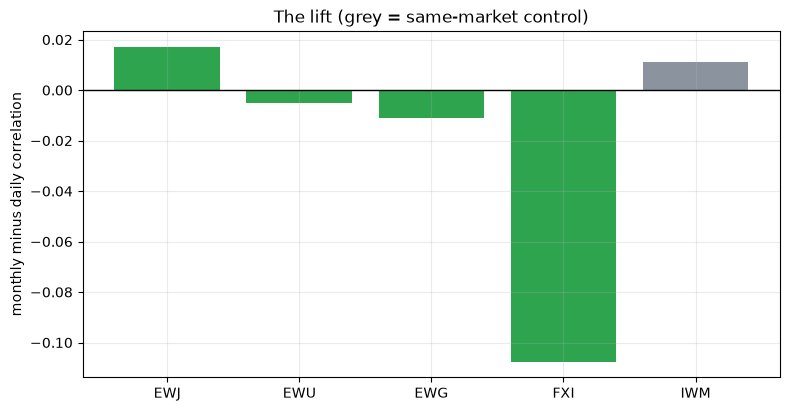

In [3]:
tbl = st.bias_table(common, data.US, list(data.FOREIGN) + [data.CONTROL])
show = tbl[[f"corr_{f}" for f in st.FREQS] + ["corr_lift"]].copy()
show.columns = list(st.FREQS) + ["lift"]
print(show.round(3).to_string())
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#8b949e" if a == data.CONTROL else "#2ea44f" for a in show.index]
ax.bar(show.index, show["lift"], color=colors)
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("monthly minus daily correlation")
ax.set_title("The lift (grey = same-market control)")
plt.show()

### 3.2 The betas, three ways

       beta_naive  beta_dimson  beta_sw  lead_coef  lag_coef
asset                                                       
EWJ        0.8120       0.7770   0.7730     0.0010   -0.0330
EWU        0.9700       0.9680   0.9670     0.0010   -0.0030
EWG        1.0740       1.0970   1.0990     0.0210    0.0010
FXI        1.1610       1.0520   1.0400     0.0440   -0.1430
IWM        1.1340       1.1600   1.1620     0.0290   -0.0060


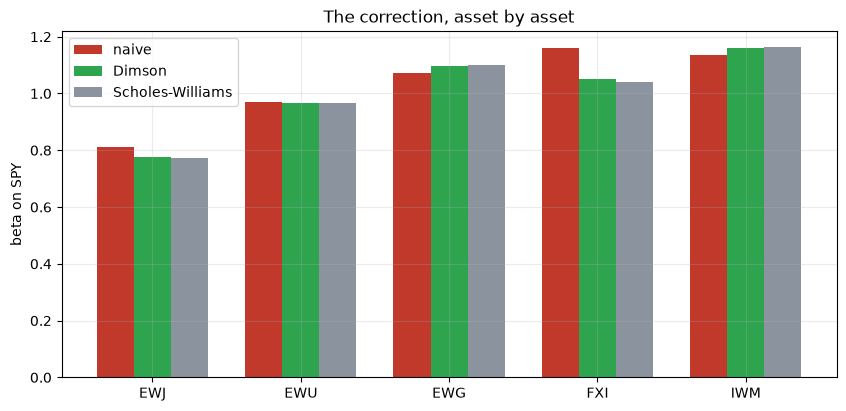

In [4]:
b = tbl[["beta_naive", "beta_dimson", "beta_sw", "lead_coef", "lag_coef"]]
print(b.round(3).to_string())
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(b))
ax.bar(x - 0.25, b["beta_naive"], width=0.25, color="#c0392b", label="naive")
ax.bar(x, b["beta_dimson"], width=0.25, color="#2ea44f", label="Dimson")
ax.bar(x + 0.25, b["beta_sw"], width=0.25, color="#8b949e", label="Scholes-Williams")
ax.set_xticks(x); ax.set_xticklabels(b.index)
ax.set_ylabel("beta on SPY"); ax.legend()
ax.set_title("The correction, asset by asset")
plt.show()

> \U0001F4A1 **In plain words.** The two corrections were derived differently and agree closely,
> which is the usual sign that both are measuring something real rather than each other.

### 3.3 The lead-lag structure in numbers

       EWJ     EWU     EWG     FXI     IWM
-3  0.0080  0.0080  0.0090 -0.0000 -0.0030
-2 -0.0100  0.0090  0.0260 -0.0270  0.0060
-1 -0.0760 -0.0840 -0.0690 -0.0420 -0.0690
0   0.7540  0.8270  0.8200  0.6710  0.8930
1  -0.1080 -0.0880 -0.0850 -0.1520 -0.0970
2  -0.0230 -0.0030 -0.0170 -0.0020  0.0130
3   0.0120 -0.0030  0.0060  0.0150  0.0120


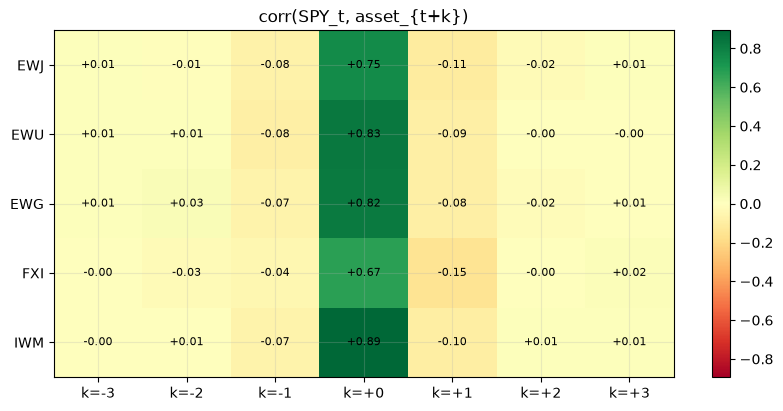

In [5]:
prof = pd.DataFrame({a: st.lead_lag_profile(rets, data.US, a, max_lag=3)
                     for a in list(data.FOREIGN) + [data.CONTROL]})
print(prof.round(3).to_string())
fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(prof.T.values, cmap="RdYlGn", aspect="auto",
               vmin=-abs(prof.values).max(), vmax=abs(prof.values).max())
ax.set_xticks(range(len(prof.index))); ax.set_xticklabels([f"k={k:+d}" for k in prof.index])
ax.set_yticks(range(prof.shape[1])); ax.set_yticklabels(prof.columns)
for i in range(prof.shape[1]):
    for j in range(prof.shape[0]):
        ax.text(j, i, f"{prof.T.values[i, j]:+.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax)
ax.set_title("corr(SPY_t, asset_{t+k})")
plt.show()

### 3.4 The optimiser

                        promised  delivered  understatement  cost vs best  max weight gap
estimation step (days)                                                                   
1                         0.1763     0.1535         -0.1293        0.0343          0.1841
5                         0.1535     0.1506         -0.0192        0.0148          0.1583
21                        0.1484     0.1484          0.0000        0.0000          0.0000

same-market control (SPY + IWM): understatement -18.7%


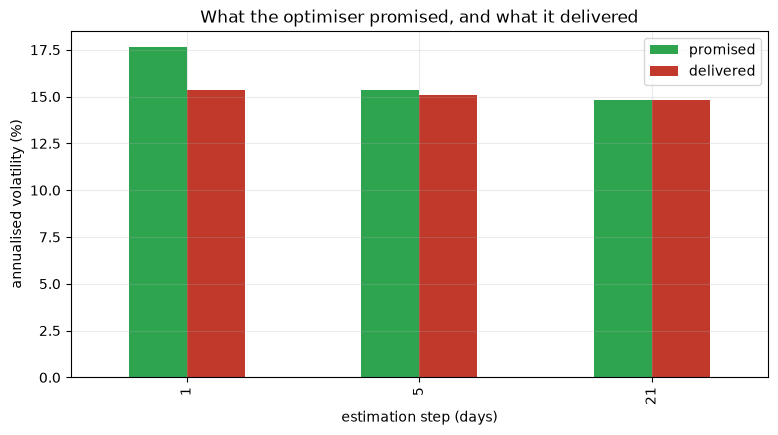

In [6]:
assets = [data.US] + list(data.FOREIGN)
rows = []
for est in (1, 5, 21):
    imp = st.portfolio_impact(common, assets, step_estimate=est, step_truth=21)
    rows.append({"estimation step (days)": est, "promised": imp["promised_vol"],
                 "delivered": imp["delivered_vol"], "understatement": imp["understatement"],
                 "cost vs best": imp["cost_of_bad_matrix"],
                 "max weight gap": imp["max_weight_gap"]})
d = pd.DataFrame(rows).set_index("estimation step (days)")
print(d.round(4).to_string())
ctrl = st.portfolio_impact(common, [data.US, data.CONTROL], 1, 21)
print(f"\nsame-market control (SPY + {data.CONTROL}): understatement "
      f"{ctrl['understatement']:+.1%}")
fig, ax = plt.subplots(figsize=(9, 4.5))
(d[["promised", "delivered"]] * 100).plot.bar(ax=ax, color=["#2ea44f", "#c0392b"])
ax.set_ylabel("annualised volatility (%)")
ax.set_title("What the optimiser promised, and what it delivered")
ax.legend(title="")
plt.show()

### 3.5 Is the world becoming more synchronous?

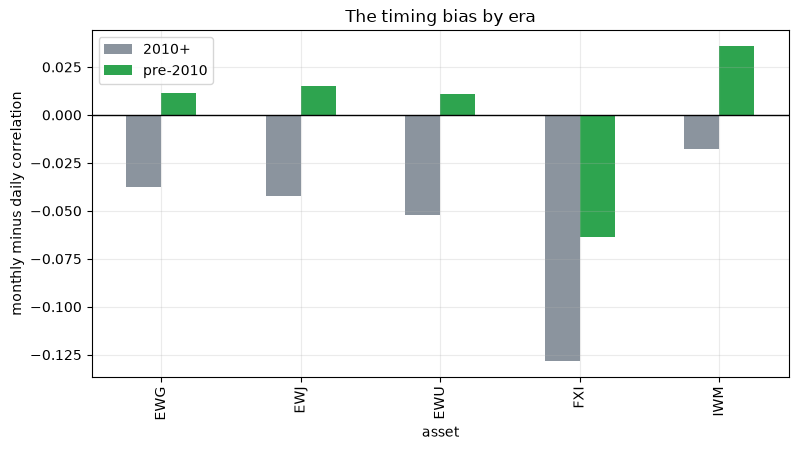

era,2010+,pre-2010
asset,,
EWG,-0.0380,0.0110
EWJ,-0.0430,0.0150
EWU,-0.0520,0.0110
FXI,-0.1280,-0.0640
IWM,-0.0180,0.0360


In [7]:
rows = []
for tag, sl in (("pre-2010", common.loc[:"2009-12-31"]), ("2010+", common.loc["2010-01-01":])):
    t = st.bias_table(sl, data.US, list(data.FOREIGN) + [data.CONTROL])
    for a in t.index:
        rows.append({"era": tag, "asset": a, "lift": t.loc[a, "corr_lift"],
                     "daily corr": t.loc[a, "corr_daily"]})
d = pd.DataFrame(rows).pivot(index="asset", columns="era", values="lift")
fig, ax = plt.subplots(figsize=(9, 4.5))
d.plot.bar(ax=ax, color=["#8b949e", "#2ea44f"])
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("monthly minus daily correlation"); ax.legend(title="")
ax.set_title("The timing bias by era")
plt.show()
d.round(3)

### 3.6 The synthetic control

               corr daily  corr monthly  beta naive  beta Dimson
planted delay                                                   
0.0000             0.5100        0.5130      0.5060       0.4890
0.2500             0.4200        0.4820      0.3810       0.4850
0.5000             0.2910        0.4280      0.2540       0.4960
0.7500             0.1420        0.4670      0.1270       0.5070


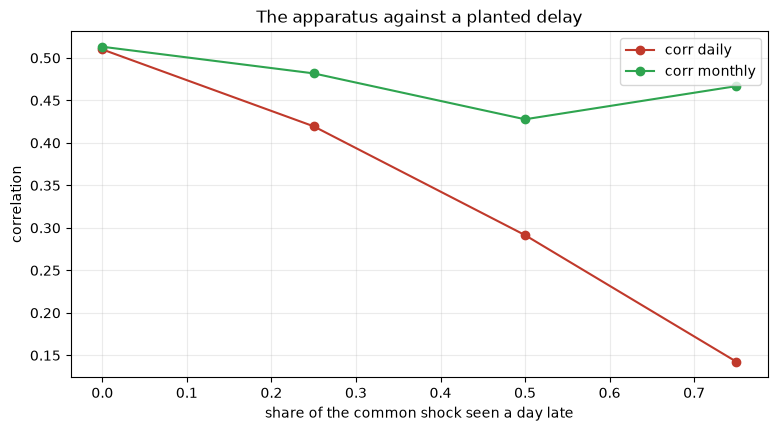

In [8]:
rng = np.random.default_rng(973)
rows = []
for delay in (0.0, 0.25, 0.5, 0.75):
    n = 8000
    f = rng.normal(0, 0.01, n)
    e1, e2 = rng.normal(0, 0.01, n), rng.normal(0, 0.01, n)
    bser = (1 - delay) * f + delay * np.concatenate([[0.0], f[:-1]]) + e2
    sim = pd.DataFrame({"A": 100 * np.cumprod(1 + f + e1), "B": 100 * np.cumprod(1 + bser)},
                       index=pd.bdate_range("1995-01-02", periods=n))
    agg = st.aggregated_correlation(sim, "A", "B")
    r = st.to_returns(sim)
    rows.append({"planted delay": delay, "corr daily": agg.loc["daily", "correlation"],
                 "corr monthly": agg.loc["monthly", "correlation"],
                 "beta naive": st.ols_beta(r["B"], r["A"]),
                 "beta Dimson": st.dimson_beta(r["B"], r["A"])["beta"]})
d = pd.DataFrame(rows).set_index("planted delay")
print(d.round(3).to_string())
fig, ax = plt.subplots(figsize=(9, 4.5))
d[["corr daily", "corr monthly"]].plot(ax=ax, marker="o", color=["#c0392b", "#2ea44f"])
ax.set_ylabel("correlation"); ax.set_xlabel("share of the common shock seen a day late")
ax.set_title("The apparatus against a planted delay")
plt.show()

## 4 · The verdict

In [9]:
summary = tbl[["corr_daily", "corr_monthly", "corr_lift", "beta_naive",
                "beta_dimson", "lag_coef"]].copy()
summary["is control"] = summary.index == data.CONTROL
print(summary.round(3).to_string())
imp = st.portfolio_impact(common, [data.US] + list(data.FOREIGN), 1, 21)
print(f"\nportfolio understatement: {imp['understatement']:+.1%}; "
      f"foreign tapes lifting > 0.10: "
      f"{int((tbl.drop(index=[data.CONTROL])['corr_lift'] > 0.10).sum())}/{len(data.FOREIGN)}; "
      f"control lift {tbl.loc[data.CONTROL, 'corr_lift']:+.3f}")

       corr_daily  corr_monthly  corr_lift  beta_naive  beta_dimson  lag_coef  is control
asset                                                                                    
EWJ        0.7540        0.7710     0.0170      0.8120       0.7770   -0.0330       False
EWU        0.8270        0.8220    -0.0050      0.9700       0.9680   -0.0030       False
EWG        0.8200        0.8090    -0.0110      1.0740       1.0970    0.0010       False
FXI        0.6710        0.5630    -0.1080      1.1610       1.0520   -0.1430       False
IWM        0.8930        0.9040     0.0110      1.1340       1.1600   -0.0060        True

portfolio understatement: -12.9%; foreign tapes lifting > 0.10: 0/4; control lift +0.011


## 5 · Going further

- **Burns-Engle-Mezrich (1998)** give a full asynchronous-covariance estimator for portfolio
  work — the industrial version of what section 3.4 approximates by changing frequency.
- **Index futures**, which trade nearly 24 hours, should show a far smaller lift; that is the
  cleanest possible falsification test of the mechanism.
- **Realised covariance from intraday overlapping windows** (the Hayashi-Yoshida estimator)
  handles asynchrony directly and is the modern answer.
- **Crisis conditioning**: the correction is largest exactly when correlations matter most.